In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Step-1 : Data Cleaning

In [3]:
df = pd.read_csv("spam.csv",encoding="latin1")
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
5365,spam,Camera - You are awarded a SiPix Digital Camer...,NaN,NaN,NaN
1908,ham,Hello beautiful r u ok? I've kinda ad a row wi...,NaN,NaN,NaN
2591,ham,Still work going on:)it is very small house.,NaN,NaN,NaN
3161,ham,I can't describe how lucky you are that I'm ac...,NaN,NaN,NaN
4975,ham,You are gorgeous! keep those pix cumming :) th...,NaN,NaN,NaN


In [4]:
df.describe()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


In [5]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [6]:
df.shape

(5572, 5)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [8]:
# we need to remove the last three rows due to less non-null values

df.drop(columns=['Unnamed: 2','Unnamed: 3',"Unnamed: 4"],inplace=True)

In [9]:
df.sample(5)

,v1,v2
3311,ham,I know you are serving. I mean what are you do...
4053,ham,dont make ne plans for nxt wknd coz she wants ...
1133,ham,"As I entered my cabin my PA said, '' Happy B'd..."
752,ham,Dont gimme that lip caveboy
2809,ham,Mm so you asked me not to call radio


In [10]:
# renaming the feature name to make it sense
df.rename(columns={"v1":"target",'v2':"text"},inplace=True)
df.sample(5)

,target,text
388,spam,4mths half price Orange line rental & latest c...
195,ham,Gud mrng dear hav a nice day
2507,ham,Yup...
3693,ham,Ok im not sure what time i finish tomorrow but...
3489,ham,Huh but i got lesson at 4 lei n i was thinkin ...


### label Encoding

In [11]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

df['target'] = encoder.fit_transform(df['target'])

In [12]:
df.head(5)

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [13]:
# checking missing values 
df.isnull().sum()

target    0
text      0
dtype: int64

In [14]:
# checking for duplicated values
df.duplicated().sum()

np.int64(403)

In [15]:
df = df.drop_duplicates(keep='first')

In [16]:
df.duplicated().sum()

np.int64(0)

### Step-2 Exploratory Data Analysis (EDA)

In [17]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

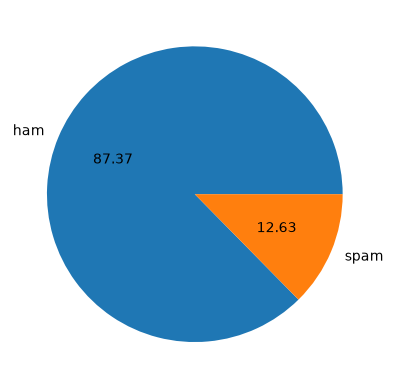

In [18]:
# Visualizing the spam distribution using pie-chart

plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [19]:
# Data is clearly imbalanced

### to classify on the basis of characters , words and sentences , we need to download the nltk library using pip install nltk

In [20]:
import nltk

In [21]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [22]:
# classify the lenght of each row respectively

df['sum_characters'] = df['text'].apply(len)

In [23]:
df.head()

,target,text,sum_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [24]:
# classifying on the basis of words on each row

df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [25]:
df.head(5)

,target,text,sum_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [26]:
# classifying on the basis of sentence using sen_tokenize()

# df['text'].apply(lambda x:nltk.sent_tokenize(x))
df['sent_sum'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [27]:
df

,target,text,sum_characters,num_words,sent_sum
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1
...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35,4
5568,0,Will Ì_ b going to esplanade fr home?,37,9,1
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2
5570,0,The guy did some bitching but I acted like i'd...,125,27,1


In [28]:
df[['sum_characters','num_words','sent_sum']].describe()

,sum_characters,num_words,sent_sum
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [29]:
# description of ham message
df[df['target'] == 0 ][['sum_characters','num_words','sent_sum']].describe()

,sum_characters,num_words,sent_sum
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [30]:
df[df['target'] == 1][['sum_characters','num_words','sent_sum']].describe()

,sum_characters,num_words,sent_sum
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


### Visualizing the datasets using seaborn

<Axes: xlabel='sum_characters', ylabel='Count'>

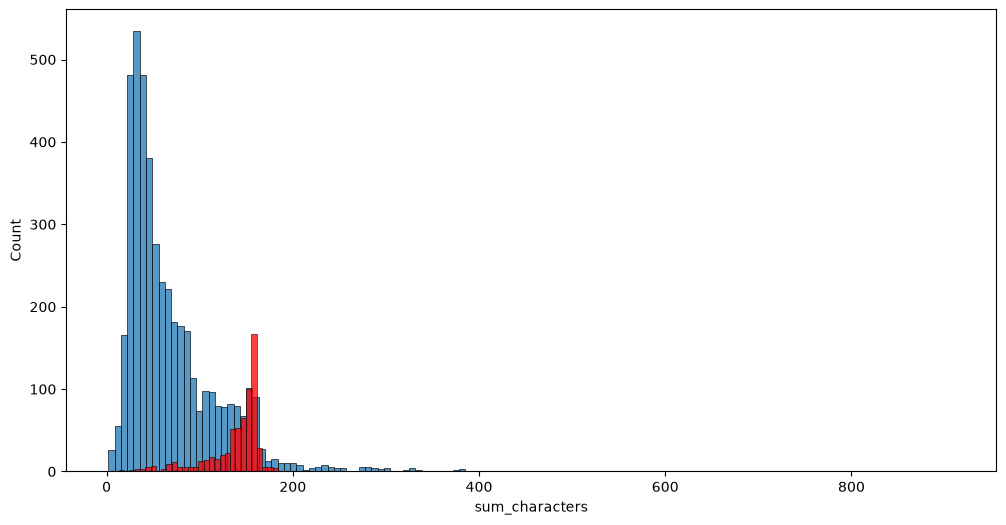

In [43]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['sum_characters'])
sns.histplot(df[df['target'] == 1]['sum_characters'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

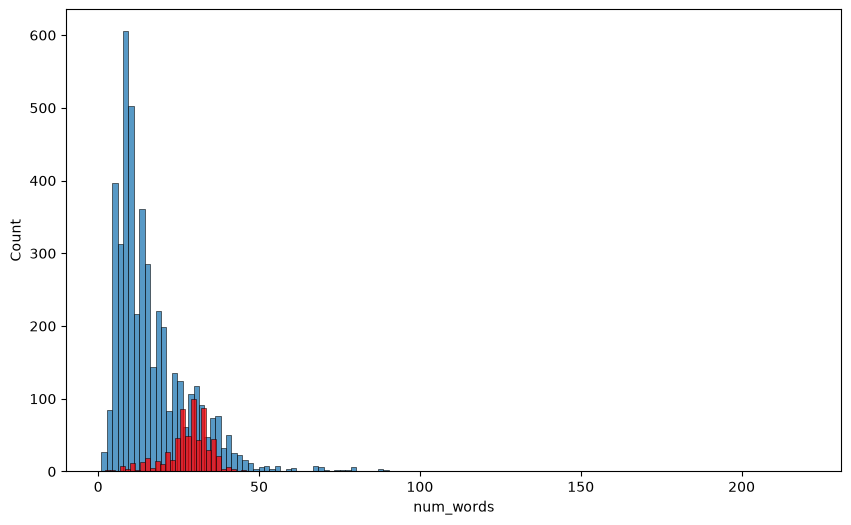

In [44]:
plt.figure(figsize=(10,6))
sns.histplot(df[df['target'] == 0]['num_words'])
sns.histplot(df[df['target'] == 1]['num_words'] , color='red')

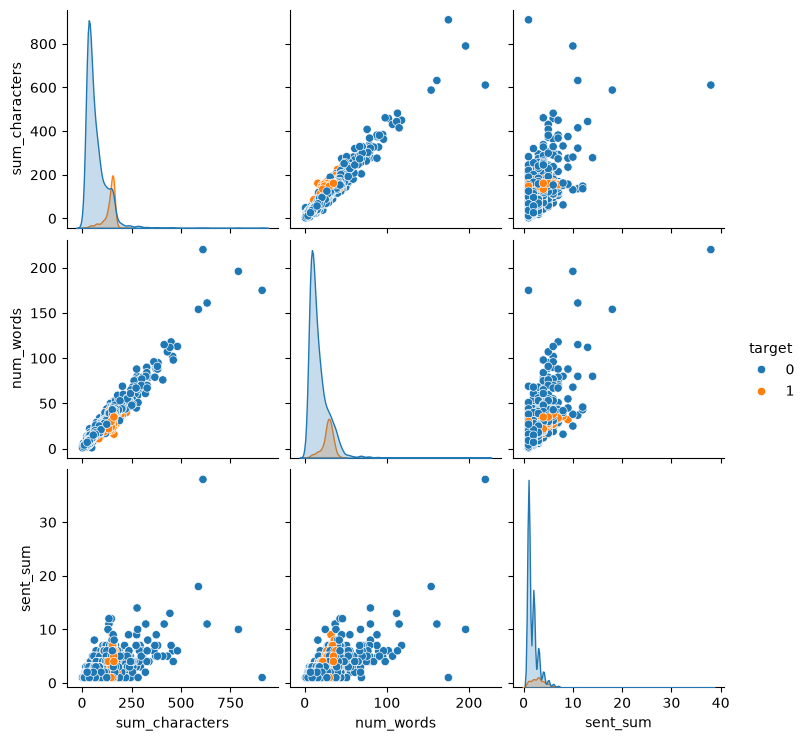

In [45]:
sns.pairplot(df,hue='target')

<Axes: >

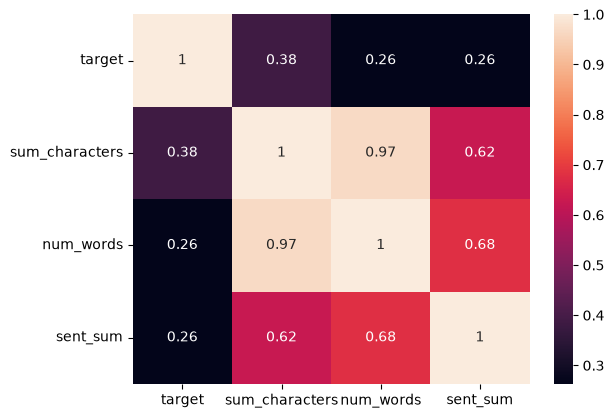

In [48]:
sns.heatmap(df.select_dtypes(include='number').corr(),annot=True)

### Step-3 Data Preprocessing
 - Lower Case
 - Tokenization
 - Removing Special Characters
 - Removing Stop words and punctuation
 - Stemming